In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
sns.set()
from sklearn import metrics
from sklearn.linear_model import LinearRegression

In [3]:
df=pd.read_excel(r'C:\Users\TOSHIBA\Downloads\lgd_data.xlsx')
df
#asili deyisen lgd% dir

,Exposure Amount ($),Credit Score,Loan Term (Months),Interest Rate (%),Income ($),Loan to Value Ratio (%),Debt to Income Ratio (%),Employment History (Years),Previous Defaults,Home Ownership,Loan Purpose,Loan Type,Region,LGD%
0,238203,729,36,3.81,47603,88,24,4,2,Rent,Home Improvement,Adjustable Rate,South,0.010000
1,170008,745,36,6.68,67474,71,43,4,2,Mortgage,Auto Loan,Adjustable Rate,South,0.757182
2,198937,681,24,8.38,77036,74,46,6,1,Own,Personal Loan,Fixed Rate,West,0.575147
3,262045,684,48,5.45,55083,85,24,0,0,Mortgage,Home Purchase,Adjustable Rate,West,0.009998
4,243378,758,72,6.64,70148,78,40,5,0,Mortgage,Debt Consolidation,Fixed Rate,North,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,77140,723,24,5.62,71515,91,17,3,0,Mortgage,Debt Consolidation,Adjustable Rate,North,0.009995
39996,250556,777,72,6.16,45326,88,34,3,0,Rent,Auto Loan,Fixed Rate,West,0.834943
39997,234493,827,60,5.97,48418,78,24,7,1,Rent,Debt Consolidation,Fixed Rate,West,0.897571
39998,159998,698,36,8.65,85987,73,37,6,0,Mortgage,Personal Loan,Adjustable Rate,West,0.445537


In [4]:
df.describe(include='all')

,Exposure Amount ($),Credit Score,Loan Term (Months),Interest Rate (%),Income ($),Loan to Value Ratio (%),Debt to Income Ratio (%),Employment History (Years),Previous Defaults,Home Ownership,Loan Purpose,Loan Type,Region,LGD%
count,40000.000000,40000.000000,40000.00000,40000.000000,40000.000000,40000.000000,40000.00000,40000.000000,40000.000000,40000,40000,40000,40000,40000.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,5,2,4,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Rent,Auto Loan,Adjustable Rate,North,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,13420,8163,20161,10165,NaN
mean,149811.070400,700.667300,47.91060,6.499560,60069.306750,79.982225,30.08045,5.002275,0.998925,NaN,NaN,NaN,NaN,0.320288
std,49836.964295,49.974161,17.00847,1.504729,19926.497499,9.986641,9.98215,2.015557,0.818530,NaN,NaN,NaN,NaN,0.341183
min,-82998.000000,505.000000,24.00000,0.380000,-17513.000000,37.000000,-13.00000,-5.000000,0.000000,NaN,NaN,NaN,NaN,0.009717
25%,116398.000000,667.000000,36.00000,5.480000,46567.500000,73.000000,23.00000,4.000000,0.000000,NaN,NaN,NaN,NaN,0.010001
50%,149822.500000,701.000000,48.00000,6.490000,60058.000000,80.000000,30.00000,5.000000,1.000000,NaN,NaN,NaN,NaN,0.197368
75%,183328.000000,734.000000,60.00000,7.520000,73416.750000,87.000000,37.00000,6.000000,2.000000,NaN,NaN,NaN,NaN,0.572629


In [5]:
df.isnull().sum()

Exposure Amount ($)           0
Credit Score                  0
Loan Term (Months)            0
Interest Rate (%)             0
Income ($)                    0
Loan to Value Ratio (%)       0
Debt to Income Ratio (%)      0
Employment History (Years)    0
Previous Defaults             0
Home Ownership                0
Loan Purpose                  0
Loan Type                     0
Region                        0
LGD%                          0
dtype: int64

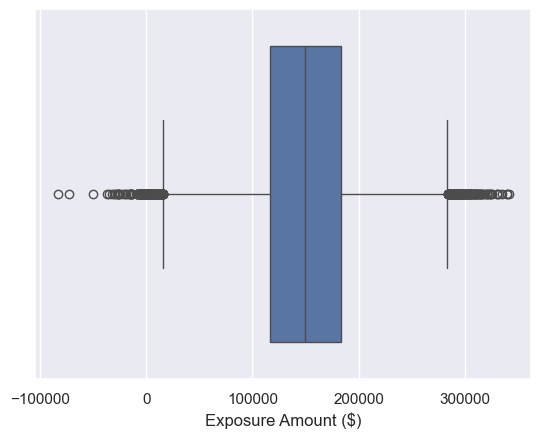

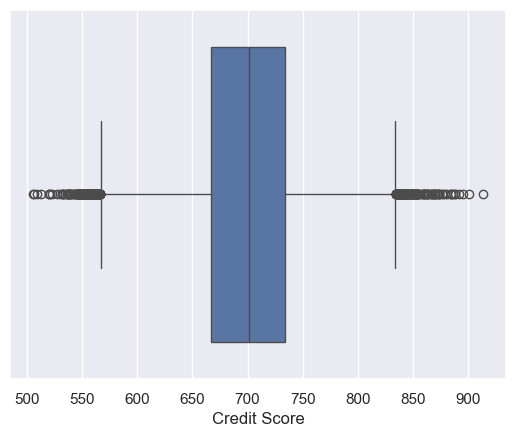

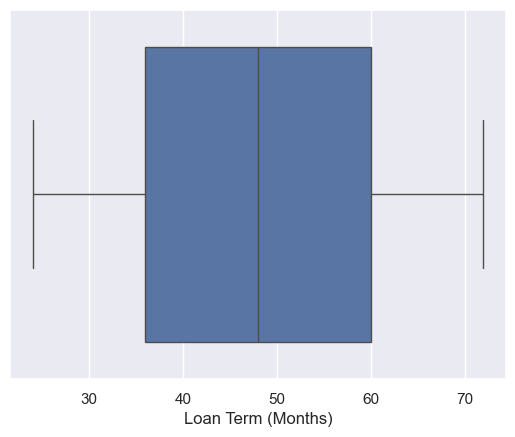

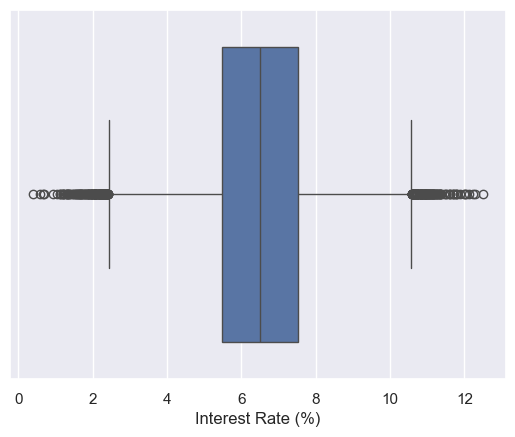

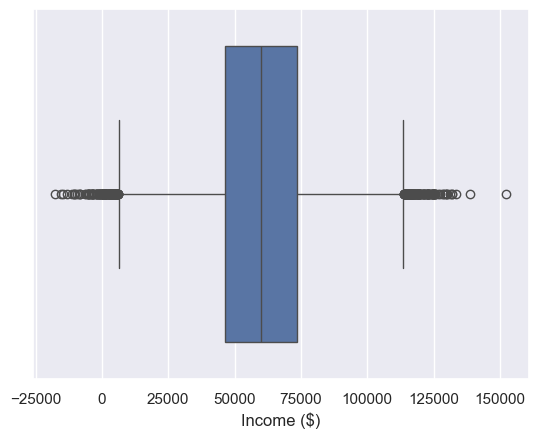

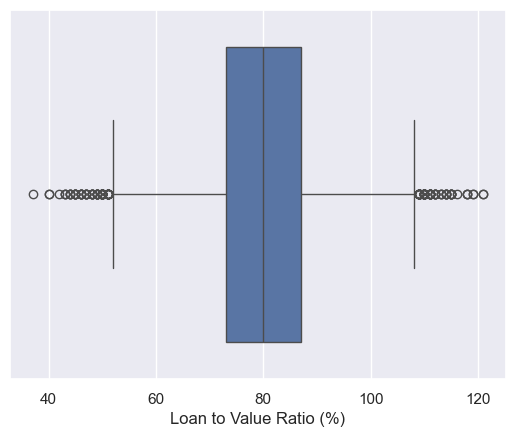

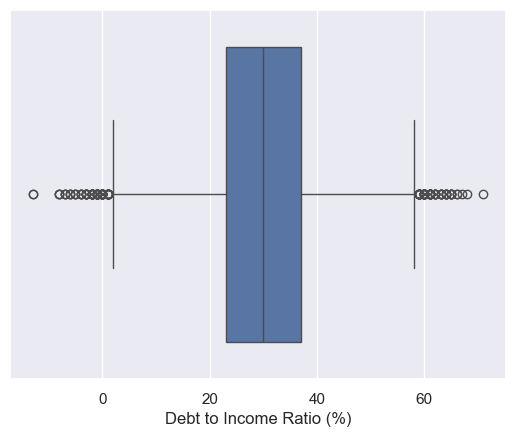

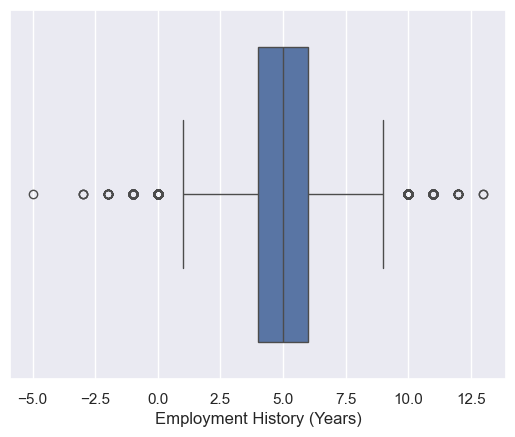

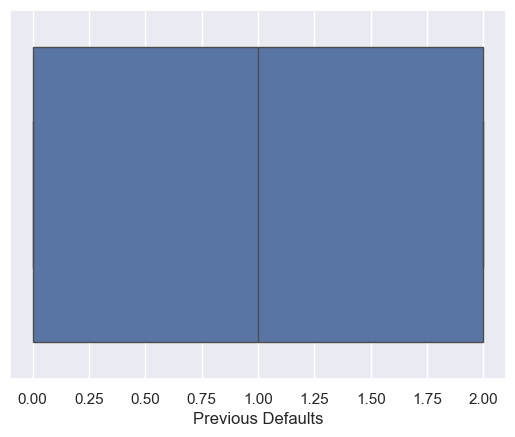

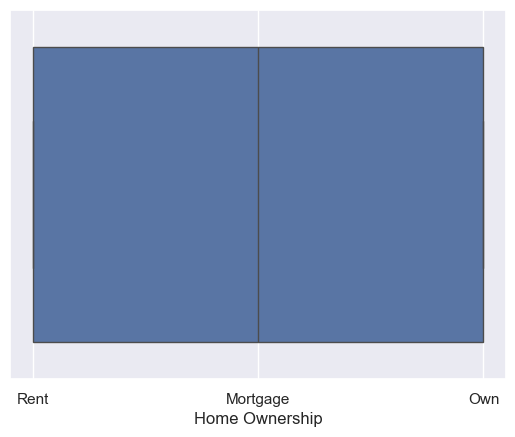

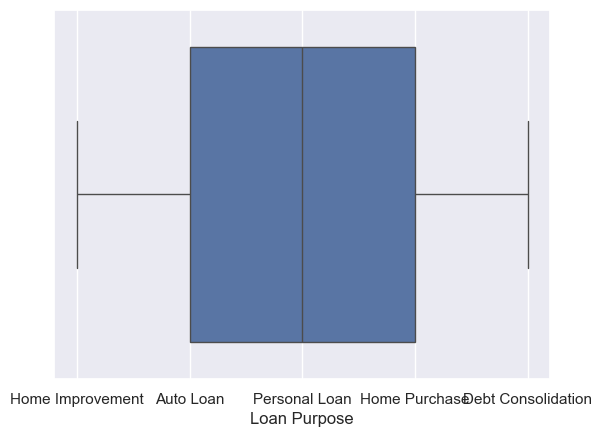

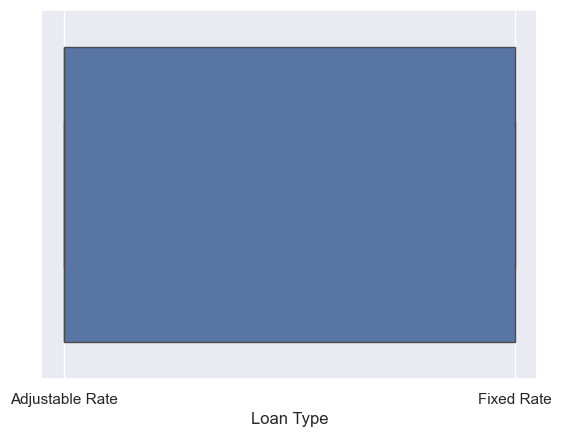

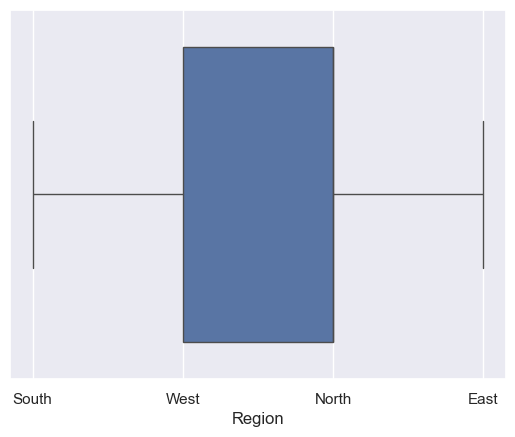

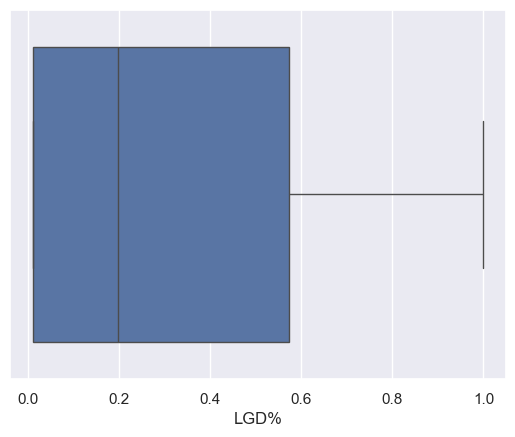

In [6]:
for i in df.columns:
    if df[i].dtypes!=object:
        sns.boxplot(data=df,x=df[i])
        plt.show()

In [7]:
q1=df.quantile(0.25,numeric_only=True)
q3=df.quantile(0.75,numeric_only=True)
IQR=q3-q1
lower=q1-1.5*IQR
upper=q3+1.5*IQR

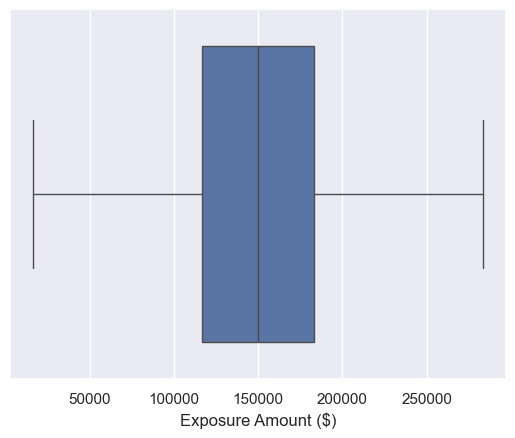

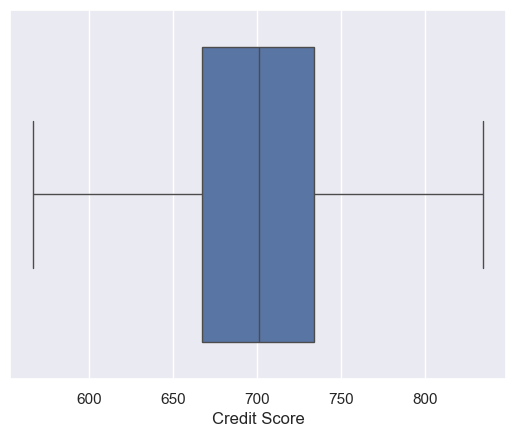

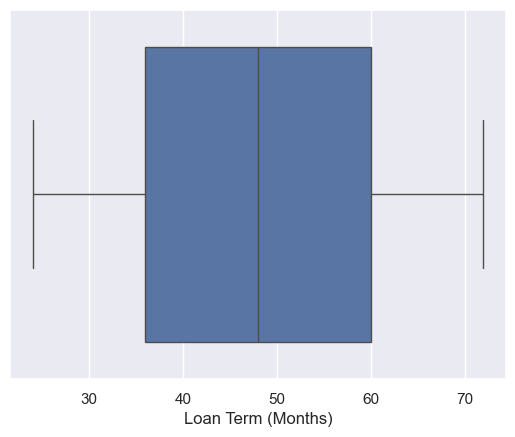

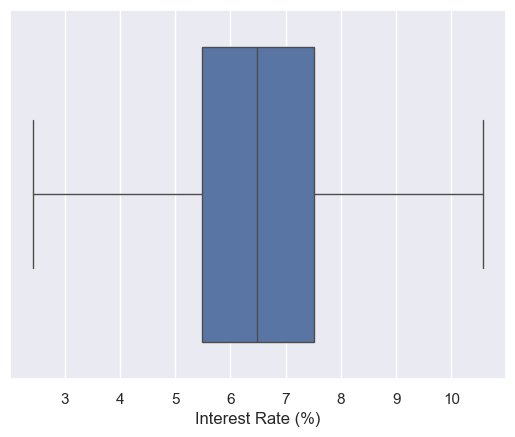

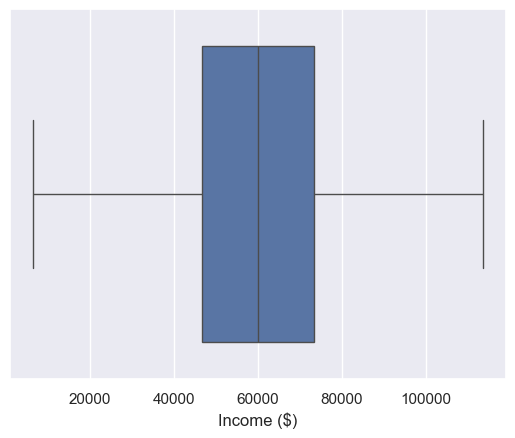

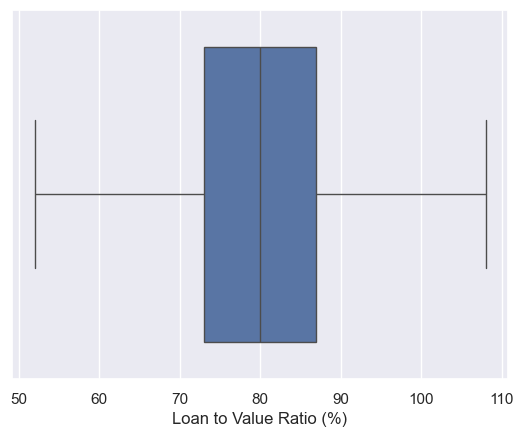

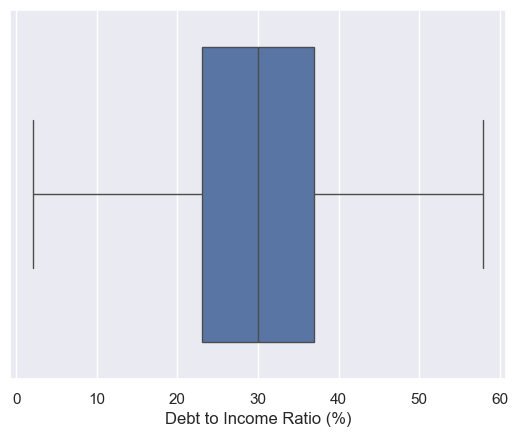

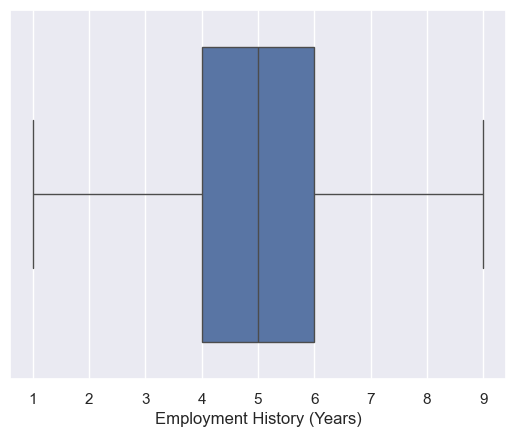

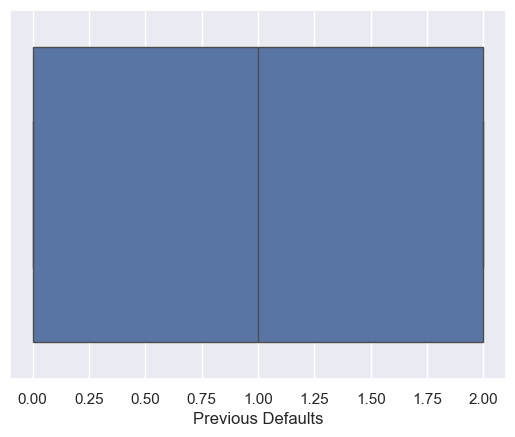

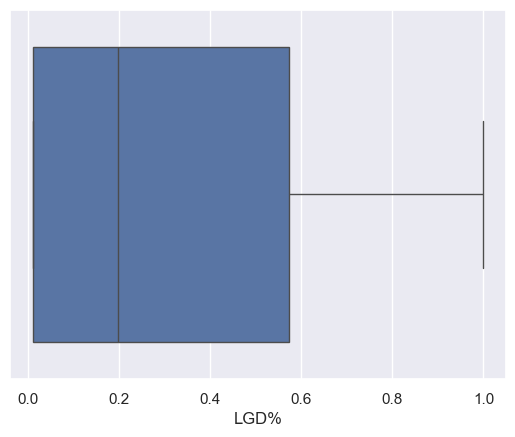

In [8]:
for i in df.columns:
    if df[i].dtype == 'int' or df[i].dtype == 'float':
        df[i]=np.where(df[i]>upper[i],upper[i],df[i])
        df[i]=np.where(df[i]<lower[i],lower[i],df[i])
        sns.boxplot(x=df[i])
        plt.show()

In [9]:
df['Income_mean_by_Region']=df.groupby('Region')['Income ($)'].transform('mean')
df['Previous_Defaults_mean_by_Credit_Score']=df.groupby('Credit Score')['Previous Defaults'].transform('mean')
df

,Exposure Amount ($),Credit Score,Loan Term (Months),Interest Rate (%),Income ($),Loan to Value Ratio (%),Debt to Income Ratio (%),Employment History (Years),Previous Defaults,Home Ownership,Loan Purpose,Loan Type,Region,LGD%,Income_mean_by_Region,Previous_Defaults_mean_by_Credit_Score
0,238203.0,729.0,36.0,3.81,47603.0,88.0,24.0,4.0,2.0,Rent,Home Improvement,Adjustable Rate,South,0.010000,60082.674340,0.938525
1,170008.0,745.0,36.0,6.68,67474.0,71.0,43.0,4.0,2.0,Mortgage,Auto Loan,Adjustable Rate,South,0.757182,60082.674340,1.022321
2,198937.0,681.0,24.0,8.38,77036.0,74.0,46.0,6.0,1.0,Own,Personal Loan,Fixed Rate,West,0.575147,60307.337702,1.030303
3,262045.0,684.0,48.0,5.45,55083.0,85.0,24.0,1.0,0.0,Mortgage,Home Purchase,Adjustable Rate,West,0.009998,60307.337702,0.985866
4,243378.0,758.0,72.0,6.64,70148.0,78.0,40.0,5.0,0.0,Mortgage,Debt Consolidation,Fixed Rate,North,1.000000,59985.178837,1.046512
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,77140.0,723.0,24.0,5.62,71515.0,91.0,17.0,3.0,0.0,Mortgage,Debt Consolidation,Adjustable Rate,North,0.009995,59985.178837,0.986395
39996,250556.0,777.0,72.0,6.16,45326.0,88.0,34.0,3.0,0.0,Rent,Auto Loan,Fixed Rate,West,0.834943,60307.337702,1.033333
39997,234493.0,827.0,60.0,5.97,48418.0,78.0,24.0,7.0,1.0,Rent,Debt Consolidation,Fixed Rate,West,0.897571,60307.337702,1.000000
39998,159998.0,698.0,36.0,8.65,85987.0,73.0,37.0,6.0,0.0,Mortgage,Personal Loan,Adjustable Rate,West,0.445537,60307.337702,0.963087


In [10]:
from scipy import stats
for i in df.columns:
    if df[i].dtype in ['int','float']:
        kstest_statistic,kstest_p_value=stats.kstest(df[i],'norm')
        print(f'column: {i}')
        print(f'p-value: {kstest_p_value}')
        
        if kstest_p_value > 0.05:
            print('Data looks normally distributed')
            print()
        else:
            print('Data does not look normally distributed')
            print()

column: Exposure Amount ($)
p-value: 0.0
Data does not look normally distributed

column: Credit Score
p-value: 0.0
Data does not look normally distributed

column: Loan Term (Months)
p-value: 0.0
Data does not look normally distributed

column: Interest Rate (%)
p-value: 0.0
Data does not look normally distributed

column: Income ($)
p-value: 0.0
Data does not look normally distributed

column: Loan to Value Ratio (%)
p-value: 0.0
Data does not look normally distributed

column: Debt to Income Ratio (%)
p-value: 0.0
Data does not look normally distributed

column: Employment History (Years)
p-value: 0.0
Data does not look normally distributed

column: Previous Defaults
p-value: 0.0
Data does not look normally distributed

column: LGD%
p-value: 0.0
Data does not look normally distributed

column: Income_mean_by_Region
p-value: 0.0
Data does not look normally distributed

column: Previous_Defaults_mean_by_Credit_Score
p-value: 0.0
Data does not look normally distributed



In [11]:
df.corr(numeric_only=True, method='spearman')

,Exposure Amount ($),Credit Score,Loan Term (Months),Interest Rate (%),Income ($),Loan to Value Ratio (%),Debt to Income Ratio (%),Employment History (Years),Previous Defaults,LGD%,Income_mean_by_Region,Previous_Defaults_mean_by_Credit_Score
Exposure Amount ($),1.000000,0.000537,-0.004889,0.007016,-0.001408,0.001700,0.001135,0.001011,0.003210,0.108719,0.000093,0.002993
Credit Score,0.000537,1.000000,0.005094,0.002438,0.003012,0.003004,-0.005423,0.002966,0.003455,0.489755,0.001896,0.010395
Loan Term (Months),-0.004889,0.005094,1.000000,-0.005708,-0.000408,0.000966,-0.002118,0.000815,-0.002210,0.337089,-0.005692,-0.004345
Interest Rate (%),0.007016,0.002438,-0.005708,1.000000,0.001770,0.000017,-0.000638,0.004275,0.003819,0.165559,-0.000407,0.002013
Income ($),-0.001408,0.003012,-0.000408,0.001770,1.000000,-0.008877,0.010637,-0.004133,-0.000187,0.405091,0.007087,0.000476
Loan to Value Ratio (%),0.001700,0.003004,0.000966,0.000017,-0.008877,1.000000,-0.000482,-0.003582,-0.000311,0.240004,0.003880,-0.008032
Debt to Income Ratio (%),0.001135,-0.005423,-0.002118,-0.000638,0.010637,-0.000482,1.000000,-0.001078,-0.003350,0.319163,0.002722,0.000826
Employment History (Years),0.001011,0.002966,0.000815,0.004275,-0.004133,-0.003582,-0.001078,1.000000,0.004300,0.160256,0.002791,-0.003018
Previous Defaults,0.003210,0.003455,-0.002210,0.003819,-0.000187,-0.000311,-0.003350,0.004300,1.000000,0.253319,-0.000845,0.076758
LGD%,0.108719,0.489755,0.337089,0.165559,0.405091,0.240004,0.319163,0.160256,0.253319,1.000000,0.005827,0.028162


In [12]:
def target_correlation(data, target, threshold=0.1):
    
    corr = df.corr(numeric_only=True, method='spearman')[target].drop(target)
    
    corr = corr[corr.abs() >= threshold]
    
    corr = corr.reindex(corr.abs().sort_values(ascending=False).index)
    
    return corr.reset_index().rename(
        columns={"index": "Variable", target: "Correlation with Target"}
    )


In [13]:
target_result = target_correlation(df, 'LGD%')

target_result

,Variable,Correlation with Target
0,Credit Score,0.489755
1,Income ($),0.405091
2,Loan Term (Months),0.337089
3,Debt to Income Ratio (%),0.319163
4,Previous Defaults,0.253319
5,Loan to Value Ratio (%),0.240004
6,Interest Rate (%),0.165559
7,Employment History (Years),0.160256
8,Exposure Amount ($),0.108719


In [14]:
def intercorrelation(data, target, threshold=0.6):
    
    corr_matrix = df.drop(columns=[target]).corr(numeric_only=True, method='spearman')
    
    mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
    
    high_corr = corr_matrix.where(mask).stack().reset_index()
    
    high_corr.columns = ["Variable 1", "Variable 2", "Correlation"]
    
    high_corr = high_corr[high_corr["Correlation"].abs() >= threshold]
    
    return high_corr.reset_index(drop=True)


In [15]:
intercorrelated_result = intercorrelation(df, 'LGD%')

intercorrelated_result

,Variable 1,Variable 2,Correlation


In [16]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(data, variables):
    vif_data = df[variables]
    vif_values = [variance_inflation_factor(vif_data.values, i) for i in range(vif_data.shape[1])]
    vif_result = pd.DataFrame({'VIF': vif_values, 'Features': variables})
    return vif_result


vif_result = calculate_vif(df, [ 
                            #'Credit Score',
                             'Income ($)',
	                         'Loan Term (Months)',
                            'Debt to Income Ratio (%)',		
                            'Previous Defaults',
                             #'Loan to Value Ratio (%)',	
                             # 'Interest Rate (%)',
                             'Employment History (Years)',	
                            'Exposure Amount ($)',	
                                                
                                        ])

vif_result


,VIF,Features
0,8.120835,Income ($)
1,7.324425,Loan Term (Months)
2,8.116730,Debt to Income Ratio (%)
3,2.405987,Previous Defaults
4,6.504986,Employment History (Years)
5,8.070681,Exposure Amount ($)


In [47]:
numeric_columns = df.select_dtypes(include='number').columns
categorical_columns = df.select_dtypes(include=['object', 'category']).columns

print("Numeric:", numeric_columns)
print("Categoric:", categorical_columns)

Numeric: Index(['Exposure Amount ($)', 'Credit Score', 'Loan Term (Months)',
       'Interest Rate (%)', 'Income ($)', 'Loan to Value Ratio (%)',
       'Debt to Income Ratio (%)', 'Employment History (Years)',
       'Previous Defaults', 'LGD%', 'Income_mean_by_Region',
       'Previous_Defaults_mean_by_Credit_Score'],
      dtype='str')
Categoric: Index(['Home Ownership', 'Loan Purpose', 'Loan Type', 'Region'], dtype='str')


C:\Users\TOSHIBA\AppData\Local\Temp\ipykernel_4000\1632532987.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=['object', 'category']).columns


In [18]:
df=df[['Exposure Amount ($)', 'Loan Term (Months)',
       'Income ($)', 
       'Debt to Income Ratio (%)', 'Employment History (Years)',
       'Previous Defaults', 'Home Ownership', 'Loan Purpose', 'Loan Type',
       'Region', 'Previous_Defaults_mean_by_Credit_Score',
       'Income_mean_by_Region','LGD%']]
df

,Exposure Amount ($),Loan Term (Months),Income ($),Debt to Income Ratio (%),Employment History (Years),Previous Defaults,Home Ownership,Loan Purpose,Loan Type,Region,Previous_Defaults_mean_by_Credit_Score,Income_mean_by_Region,LGD%
0,238203.0,36.0,47603.0,24.0,4.0,2.0,Rent,Home Improvement,Adjustable Rate,South,0.938525,60082.674340,0.010000
1,170008.0,36.0,67474.0,43.0,4.0,2.0,Mortgage,Auto Loan,Adjustable Rate,South,1.022321,60082.674340,0.757182
2,198937.0,24.0,77036.0,46.0,6.0,1.0,Own,Personal Loan,Fixed Rate,West,1.030303,60307.337702,0.575147
3,262045.0,48.0,55083.0,24.0,1.0,0.0,Mortgage,Home Purchase,Adjustable Rate,West,0.985866,60307.337702,0.009998
4,243378.0,72.0,70148.0,40.0,5.0,0.0,Mortgage,Debt Consolidation,Fixed Rate,North,1.046512,59985.178837,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,77140.0,24.0,71515.0,17.0,3.0,0.0,Mortgage,Debt Consolidation,Adjustable Rate,North,0.986395,59985.178837,0.009995
39996,250556.0,72.0,45326.0,34.0,3.0,0.0,Rent,Auto Loan,Fixed Rate,West,1.033333,60307.337702,0.834943
39997,234493.0,60.0,48418.0,24.0,7.0,1.0,Rent,Debt Consolidation,Fixed Rate,West,1.000000,60307.337702,0.897571
39998,159998.0,36.0,85987.0,37.0,6.0,0.0,Mortgage,Personal Loan,Adjustable Rate,West,0.963087,60307.337702,0.445537


In [19]:
df = pd.get_dummies(df, drop_first=True, dtype=int)

df

,Exposure Amount ($),Loan Term (Months),Income ($),Debt to Income Ratio (%),Employment History (Years),Previous Defaults,Previous_Defaults_mean_by_Credit_Score,Income_mean_by_Region,LGD%,Home Ownership_Own,Home Ownership_Rent,Loan Purpose_Debt Consolidation,Loan Purpose_Home Improvement,Loan Purpose_Home Purchase,Loan Purpose_Personal Loan,Loan Type_Fixed Rate,Region_North,Region_South,Region_West
0,238203.0,36.0,47603.0,24.0,4.0,2.0,0.938525,60082.674340,0.010000,0,1,0,1,0,0,0,0,1,0
1,170008.0,36.0,67474.0,43.0,4.0,2.0,1.022321,60082.674340,0.757182,0,0,0,0,0,0,0,0,1,0
2,198937.0,24.0,77036.0,46.0,6.0,1.0,1.030303,60307.337702,0.575147,1,0,0,0,0,1,1,0,0,1
3,262045.0,48.0,55083.0,24.0,1.0,0.0,0.985866,60307.337702,0.009998,0,0,0,0,1,0,0,0,0,1
4,243378.0,72.0,70148.0,40.0,5.0,0.0,1.046512,59985.178837,1.000000,0,0,1,0,0,0,1,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,77140.0,24.0,71515.0,17.0,3.0,0.0,0.986395,59985.178837,0.009995,0,0,1,0,0,0,0,1,0,0
39996,250556.0,72.0,45326.0,34.0,3.0,0.0,1.033333,60307.337702,0.834943,0,1,0,0,0,0,1,0,0,1
39997,234493.0,60.0,48418.0,24.0,7.0,1.0,1.000000,60307.337702,0.897571,0,1,1,0,0,0,1,0,0,1
39998,159998.0,36.0,85987.0,37.0,6.0,0.0,0.963087,60307.337702,0.445537,0,0,0,0,0,1,0,0,0,1


In [20]:
targets = df['LGD%']

inputs = df.drop(['LGD%'],axis=1)

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(inputs)

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [22]:
inputs_scaled = scaler.transform(inputs)

df_scaled = pd.DataFrame(inputs_scaled, columns=inputs.columns)

df_scaled

,Exposure Amount ($),Loan Term (Months),Income ($),Debt to Income Ratio (%),Employment History (Years),Previous Defaults,Previous_Defaults_mean_by_Credit_Score,Income_mean_by_Region,Home Ownership_Own,Home Ownership_Rent,Loan Purpose_Debt Consolidation,Loan Purpose_Home Improvement,Loan Purpose_Home Purchase,Loan Purpose_Personal Loan,Loan Type_Fixed Rate,Region_North,Region_South,Region_West
0,1.786404,-0.700283,-0.629277,-0.612479,-0.517597,1.223032,-0.869497,0.097178,-0.709601,1.407347,-0.501484,1.988973,-0.493154,-0.496208,-0.991982,-0.583701,1.736798,-0.578274
1,0.408114,-0.700283,0.373902,1.300527,-0.517597,1.223032,0.336804,0.097178,-0.709601,-0.710557,-0.501484,-0.502772,-0.493154,-0.496208,-0.991982,-0.583701,1.736798,-0.578274
2,0.992798,-1.405823,0.856635,1.602580,0.513114,0.001313,0.451704,1.559518,1.409243,-0.710557,-0.501484,-0.502772,-0.493154,2.015284,1.008083,-0.583701,-0.575772,1.729284
3,2.268275,0.005256,-0.251653,-0.612479,-2.063665,-1.220405,-0.187995,1.559518,-0.709601,-0.710557,-0.501484,-0.502772,2.027763,-0.496208,-0.991982,-0.583701,-0.575772,1.729284
4,1.890996,1.416336,0.508897,0.998473,-0.002242,-1.220405,0.685036,-0.537423,-0.709601,-0.710557,1.994082,-0.502772,-0.493154,-0.496208,1.008083,1.713205,-0.575772,-0.578274
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39995,-1.468843,-1.405823,0.577910,-1.317271,-1.032953,-1.220405,-0.180383,-0.537423,-0.709601,-0.710557,1.994082,-0.502772,-0.493154,-0.496208,-0.991982,1.713205,-0.575772,-0.578274
39996,2.036071,1.416336,-0.744231,0.394366,-1.032953,-1.220405,0.495327,1.559518,-0.709601,1.407347,-0.501484,-0.502772,-0.493154,-0.496208,1.008083,-0.583701,-0.575772,1.729284
39997,1.711421,0.710796,-0.588132,-0.612479,1.028470,0.001313,0.015475,1.559518,-0.709601,1.407347,1.994082,-0.502772,-0.493154,-0.496208,1.008083,-0.583701,-0.575772,1.729284
39998,0.205801,-0.700283,1.308522,0.696420,0.513114,-1.220405,-0.515904,1.559518,-0.709601,-0.710557,-0.501484,-0.502772,-0.493154,2.015284,-0.991982,-0.583701,-0.575772,1.729284


In [23]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df_scaled, targets, test_size=0.2, random_state=42)

In [24]:
reg = LinearRegression()

reg.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [25]:
y_pred = reg.predict(X_test)
y_pred_train = reg.predict(X_train)

In [26]:
from sklearn import metrics


mae_test = metrics.mean_absolute_error(y_test, y_pred)
mse_test = metrics.mean_squared_error(y_test, y_pred)
rmse_test = np.sqrt(mse_test)
r2_test = metrics.r2_score(y_test, y_pred)

mae_train = metrics.mean_absolute_error(y_train, y_pred_train)
mse_train = metrics.mean_squared_error(y_train, y_pred_train)
rmse_train = np.sqrt(mse_train)
r2_train = metrics.r2_score(y_train, y_pred_train)

def adjusted_r2(r2, n, k):
    return 1 - (1 - r2) * (n - 1) / (n - k - 1)

n_train = len(y_train)
n_test = len(y_test)
k = X_train.shape[1]

adj_r2_train = adjusted_r2(r2_train, n_train, k)
adj_r2_test = adjusted_r2(r2_test, n_test, k)



results_dict = {
    'Metric': ['MAE', 'MSE', 'RMSE', 'R2', 'Adjusted R2'],
    'Train': [mae_train, mse_train, rmse_train, r2_train, adj_r2_train],
    'Test': [mae_test, mse_test, rmse_test, r2_test, adj_r2_test]
}


results_df = pd.DataFrame(results_dict)

results_df

,Metric,Train,Test
0,MAE,0.196817,0.198745
1,MSE,0.059049,0.060065
2,RMSE,0.243000,0.245081
3,R2,0.493463,0.480899
4,Adjusted R2,0.493177,0.479728


In [28]:
results = []

for i in X_train.columns: 
    X_train_single_var = X_train[[i]]
    X_test_single_var = X_test[[i]]

    reg.fit(X_train_single_var, y_train)
    
    y_pred_train_single_var = reg.predict(X_train_single_var)

    train_r2 = metrics.r2_score(y_train, y_pred_train_single_var)

    y_pred_test_single_var = reg.predict(X_test_single_var)

    test_r2 = metrics.r2_score(y_test, y_pred_test_single_var)

    results.append({'Variable': i, 'Train R2': train_r2, 'Test R2': test_r2})

results_df = pd.DataFrame(results)

results_df_sorted = results_df.sort_values(by='Test R2', ascending=False)

results_df_sorted


,Variable,Train R2,Test R2
2,Income ($),0.1731,0.1603
1,Loan Term (Months),0.1101,0.1134
3,Debt to Income Ratio (%),0.1082,0.1021
5,Previous Defaults,0.0635,0.0649
4,Employment History (Years),0.0256,0.0319
0,Exposure Amount ($),0.0133,0.0106
6,Previous_Defaults_mean_by_Credit_Score,0.0021,0.0023
15,Region_North,0.0001,0.0010
16,Region_South,0.0000,0.0007
17,Region_West,0.0000,0.0000


In [29]:
inputs = df_scaled[['Exposure Amount ($)', 'Income ($)','Debt to Income Ratio (%)', 
                      'Loan Term (Months)','Previous Defaults','Employment History (Years)']]

In [30]:
from sklearn.model_selection import train_test_split

X_train_uni, X_test_uni, y_train_uni, y_test_uni = train_test_split(inputs, targets, test_size=0.2, random_state=42)

In [31]:
reg = LinearRegression()
reg.fit(X_train_uni,y_train_uni)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [32]:
y_pred_uni = reg.predict(X_test_uni)
y_pred_train_uni = reg.predict(X_train_uni)

In [33]:
mae_test = metrics.mean_absolute_error(y_test_uni, y_pred_uni)
mse_test = metrics.mean_squared_error(y_test_uni, y_pred_uni)
rmse_test = np.sqrt(mse_test)
r2_test = metrics.r2_score(y_test_uni, y_pred_uni)

mae_train = metrics.mean_absolute_error(y_train_uni, y_pred_train_uni)
mse_train = metrics.mean_squared_error(y_train_uni, y_pred_train_uni)
rmse_train = np.sqrt(mse_train)
r2_train = metrics.r2_score(y_train_uni, y_pred_train_uni)

def adjusted_r2(r2, n, k):
    return 1 - (1 - r2) * (n - 1) / (n - k - 1)

n_train = len(y_train_uni)
n_test = len(y_test_uni)
k = X_train_uni.shape[1]

adj_r2_train = adjusted_r2(r2_train, n_train, k)
adj_r2_test = adjusted_r2(r2_test, n_test, k)

results_dict = {
    'Metric': ['MAE', 'MSE', 'RMSE', 'R2', 'Adjusted R2'],
    'Train': [mae_train, mse_train, rmse_train, r2_train, adj_r2_train],
    'Test': [mae_test, mse_test, rmse_test, r2_test, adj_r2_test]
}

results_df = pd.DataFrame(results_dict)

results_df

,Metric,Train,Test
0,MAE,0.1969,0.1987
1,MSE,0.0591,0.0601
2,RMSE,0.2432,0.2451
3,R2,0.4927,0.4809
4,Adjusted R2,0.4926,0.4805


In [ ]:
#deployment

In [50]:
df1 = pd.read_excel(r'C:\Users\TOSHIBA\Downloads\lgd_data_deploy.xlsx')

df1

,Exposure Amount ($),Credit Score,Loan Term (Months),Interest Rate (%),Income ($),Loan to Value Ratio (%),Debt to Income Ratio (%),Employment History (Years),Previous Defaults,Home Ownership,Loan Purpose,Loan Type,Region
0,153539,715,36,6.8500,57712,92,23,6,1,Mortgage,Home Improvement,Adjustable Rate,West
1,137842,713,36,6.6500,37490,83,41,7,0,Mortgage,Debt Consolidation,Fixed Rate,East
2,187289,606,72,5.0000,35857,79,46,7,1,Mortgage,Home Improvement,Adjustable Rate,East
3,98051,817,72,6.0100,37531,91,20,4,2,Mortgage,Home Improvement,Fixed Rate,East
4,120672,659,36,5.8800,84892,93,28,2,0,Rent,Debt Consolidation,Adjustable Rate,East
...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,83740,610,24,5.3700,66358,69,23,4,1,Mortgage,Debt Consolidation,Adjustable Rate,South
396,129005,635,36,7.5100,71919,84,38,5,1,Own,Debt Consolidation,Adjustable Rate,South
397,129767,760,72,6.9300,28667,98,42,4,0,Rent,Debt Consolidation,Adjustable Rate,West
398,196097,695,24,4.1200,55885,69,38,5,0,Mortgage,Home Purchase,Adjustable Rate,West


In [51]:
df1['Income_mean_by_Region']=df1.groupby('Region')['Income ($)'].transform('mean')
df1['Previous_Defaults_mean_by_Credit_Score']=df1.groupby('Credit Score')['Previous Defaults'].transform('mean')
df1

,Exposure Amount ($),Credit Score,Loan Term (Months),Interest Rate (%),Income ($),Loan to Value Ratio (%),Debt to Income Ratio (%),Employment History (Years),Previous Defaults,Home Ownership,Loan Purpose,Loan Type,Region,Income_mean_by_Region,Previous_Defaults_mean_by_Credit_Score
0,153539,715,36,6.8500,57712,92,23,6,1,Mortgage,Home Improvement,Adjustable Rate,West,60445.3762,0.2500
1,137842,713,36,6.6500,37490,83,41,7,0,Mortgage,Debt Consolidation,Fixed Rate,East,59553.8539,0.6667
2,187289,606,72,5.0000,35857,79,46,7,1,Mortgage,Home Improvement,Adjustable Rate,East,59553.8539,1.0000
3,98051,817,72,6.0100,37531,91,20,4,2,Mortgage,Home Improvement,Fixed Rate,East,59553.8539,2.0000
4,120672,659,36,5.8800,84892,93,28,2,0,Rent,Debt Consolidation,Adjustable Rate,East,59553.8539,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,83740,610,24,5.3700,66358,69,23,4,1,Mortgage,Debt Consolidation,Adjustable Rate,South,59857.0182,0.5000
396,129005,635,36,7.5100,71919,84,38,5,1,Own,Debt Consolidation,Adjustable Rate,South,59857.0182,1.3333
397,129767,760,72,6.9300,28667,98,42,4,0,Rent,Debt Consolidation,Adjustable Rate,West,60445.3762,0.0000
398,196097,695,24,4.1200,55885,69,38,5,0,Mortgage,Home Purchase,Adjustable Rate,West,60445.3762,0.0000


In [52]:
df1 = pd.get_dummies(df1, dtype=int)

In [54]:
df1=df1[['Exposure Amount ($)', 'Loan Term (Months)', 'Income ($)',
       'Debt to Income Ratio (%)', 'Employment History (Years)',
       'Previous Defaults', 'Previous_Defaults_mean_by_Credit_Score',
       'Income_mean_by_Region', 'Home Ownership_Own',
       'Home Ownership_Rent', 'Loan Purpose_Debt Consolidation',
       'Loan Purpose_Home Improvement', 'Loan Purpose_Home Purchase',
       'Loan Purpose_Personal Loan', 'Loan Type_Fixed Rate', 'Region_North',
       'Region_South', 'Region_West']]

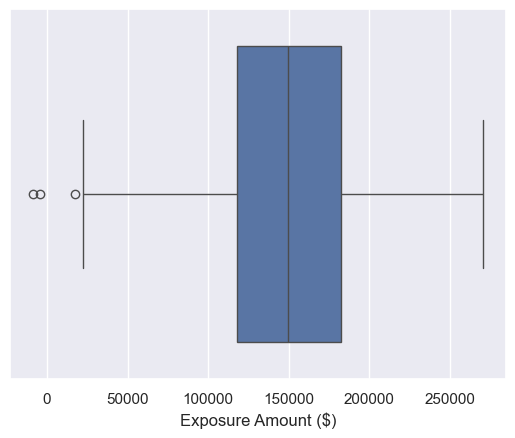

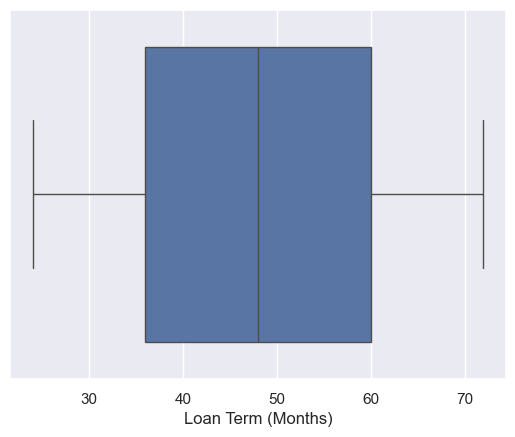

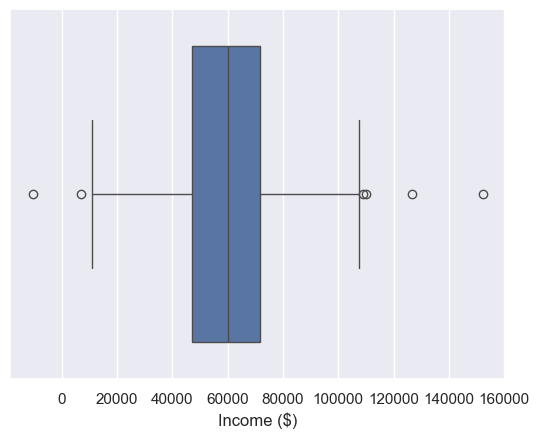

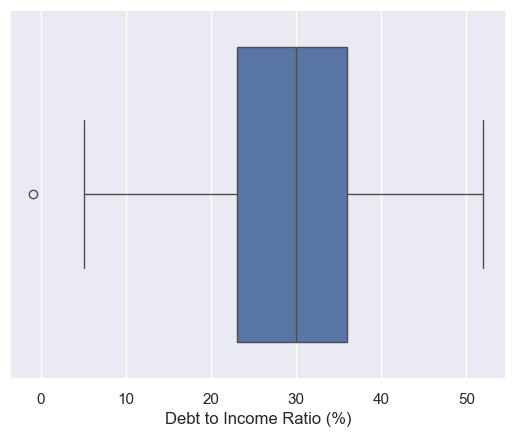

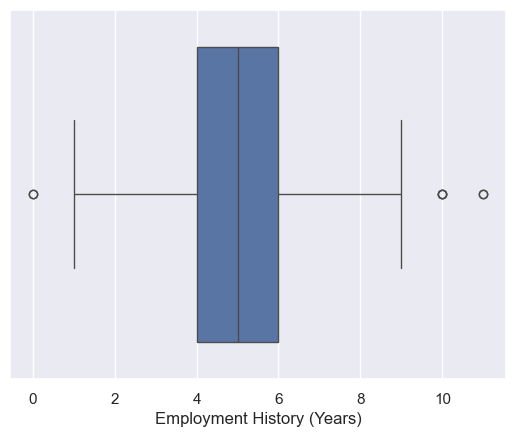

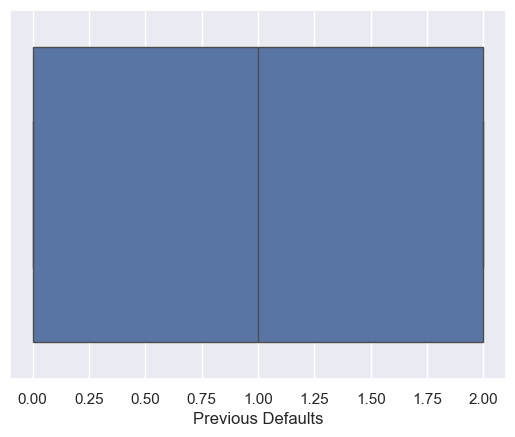

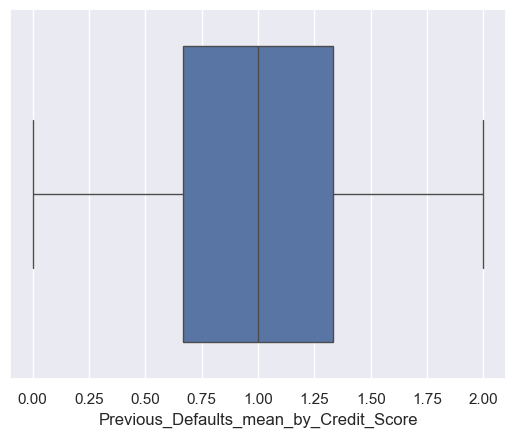

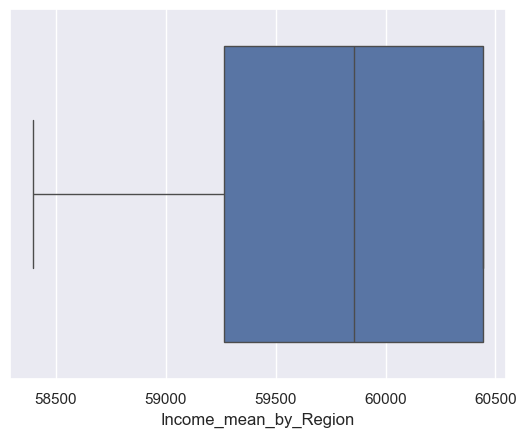

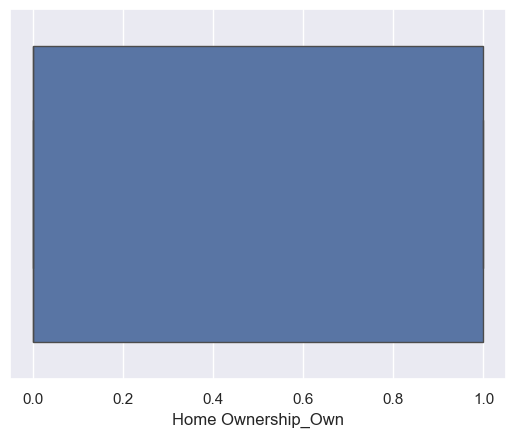

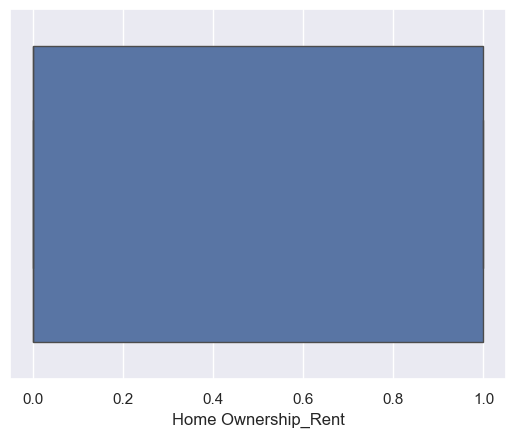

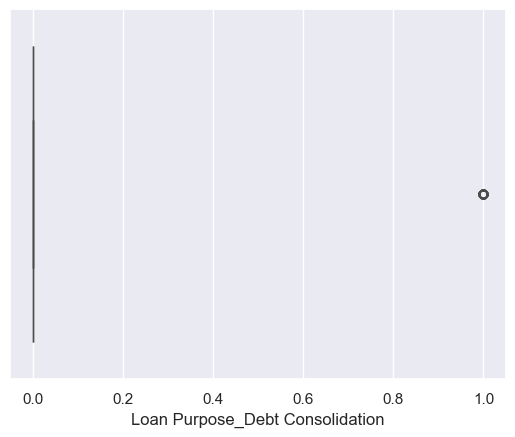

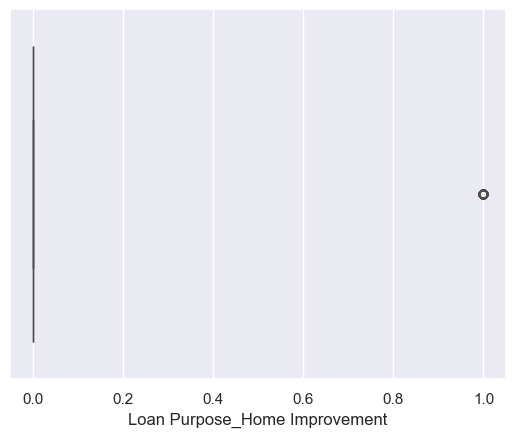

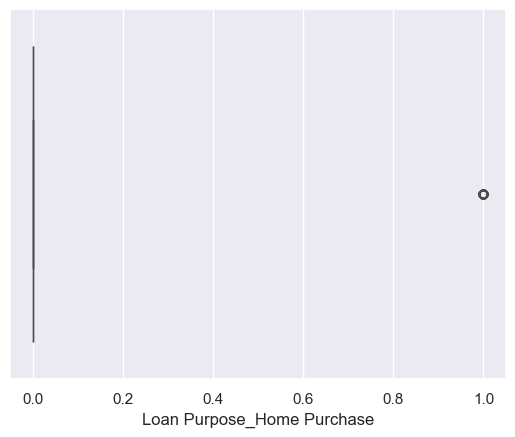

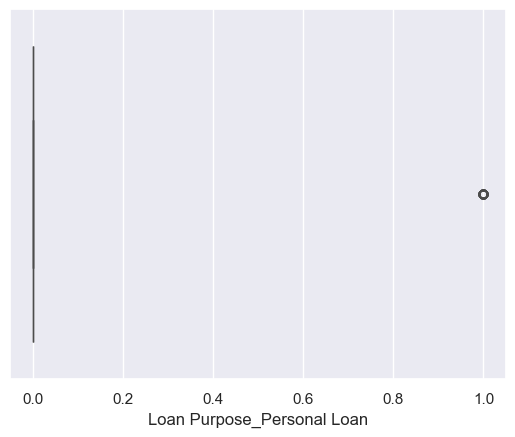

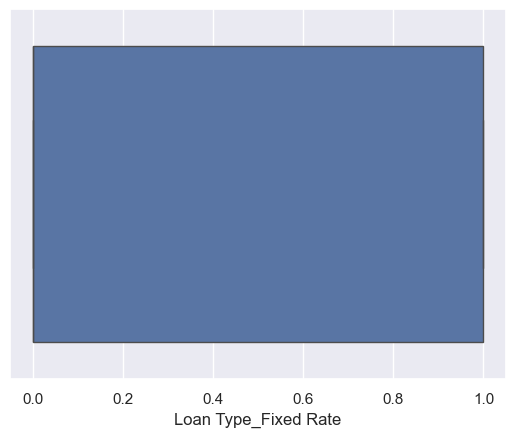

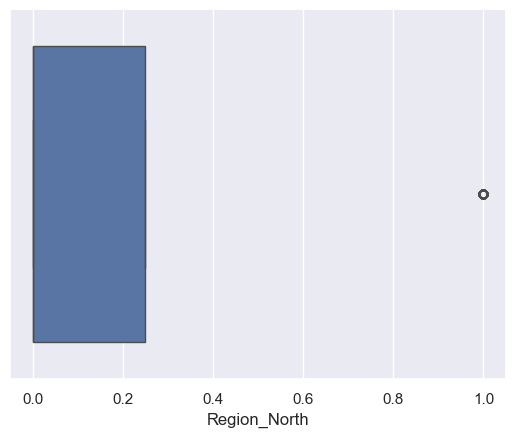

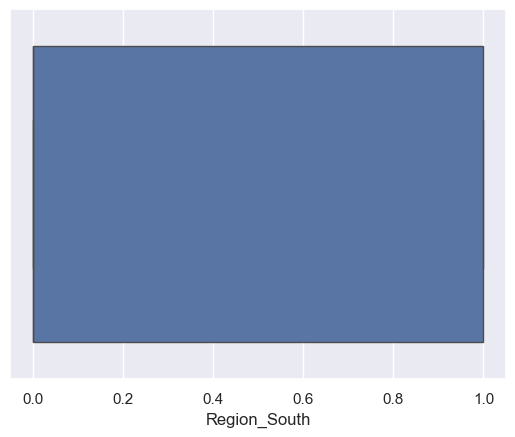

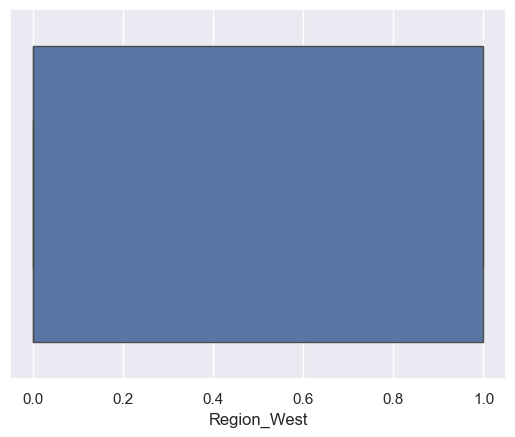

In [55]:
for i in df1.columns:
    if df1[i].dtype !=object:
        sns.boxplot(data=df1, x = i)
        plt.show()

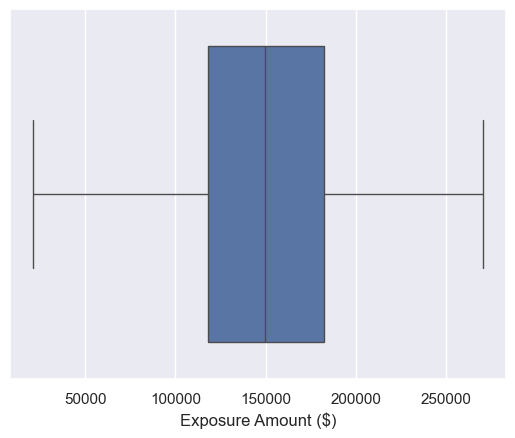

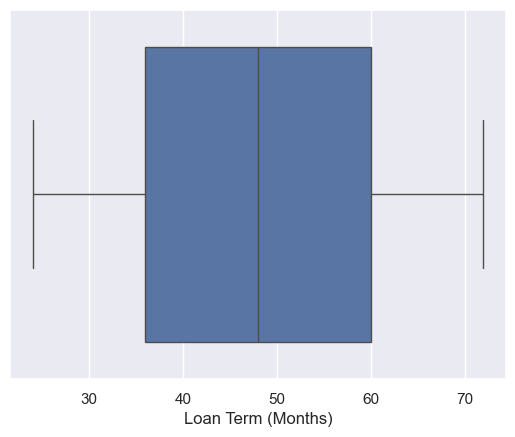

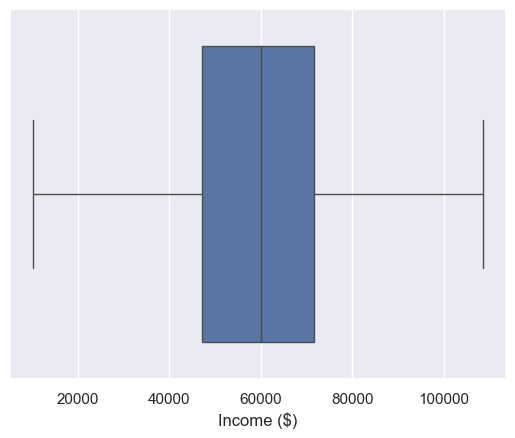

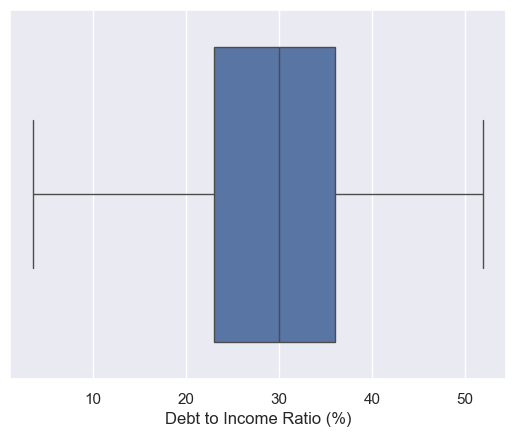

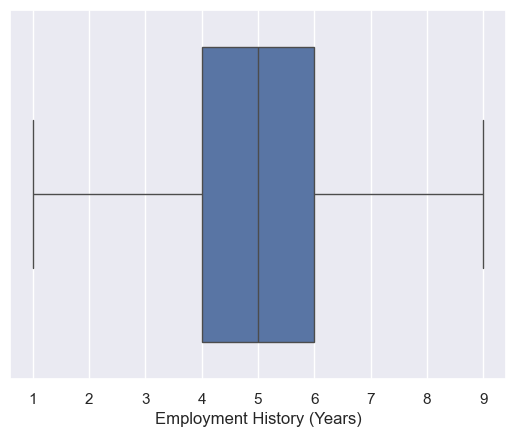

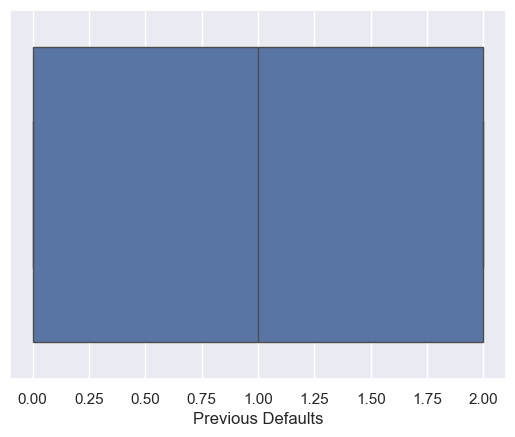

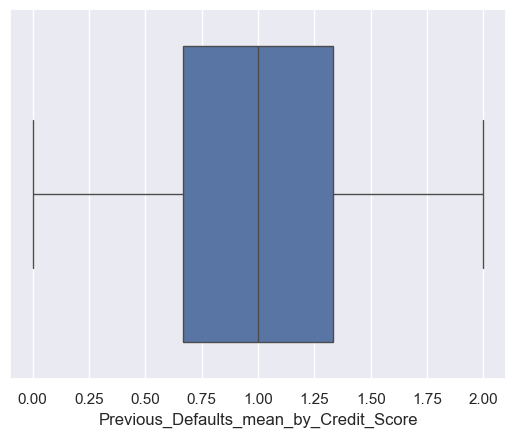

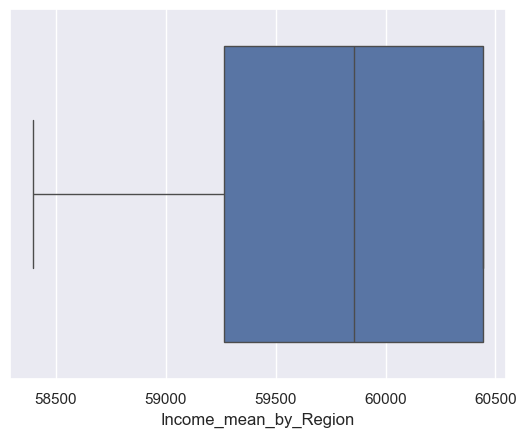

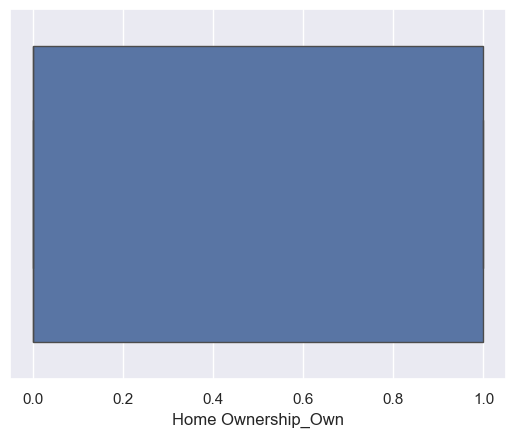

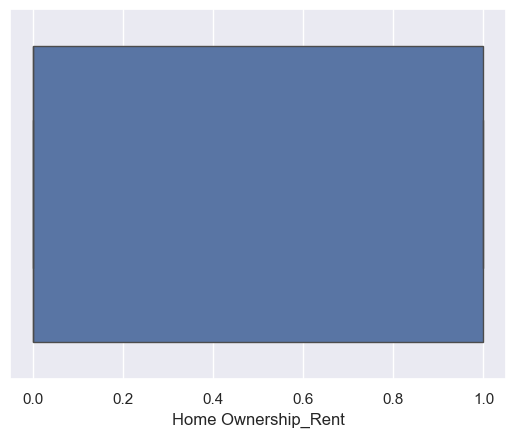

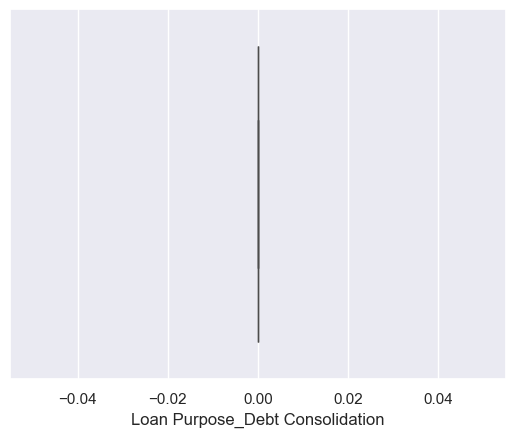

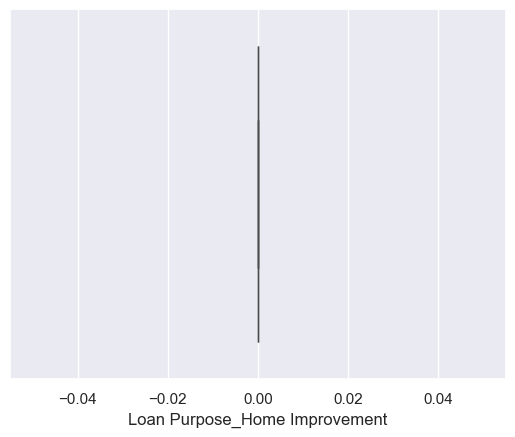

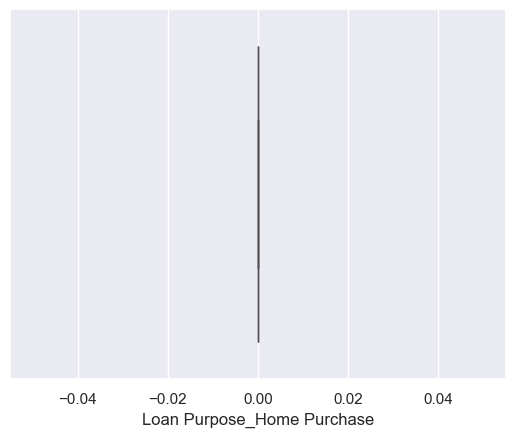

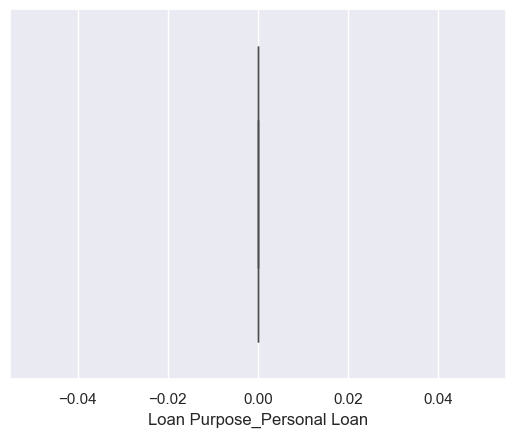

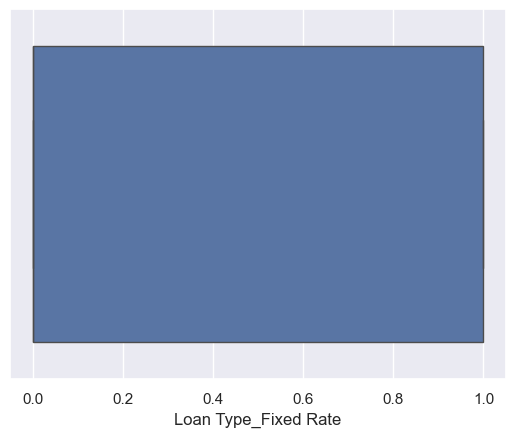

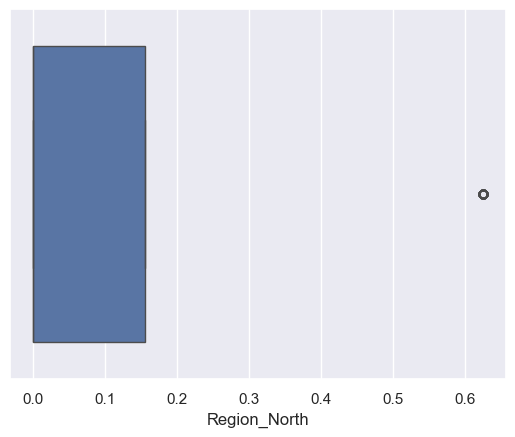

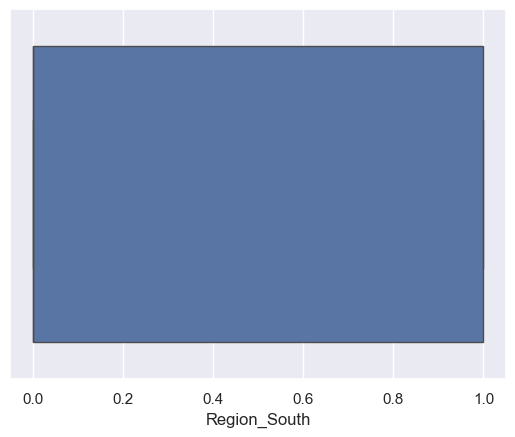

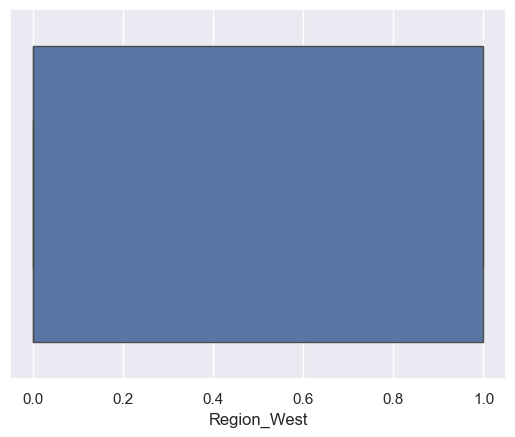

In [56]:
q1 = df1.quantile(0.25, numeric_only=True)
q3 = df1.quantile(0.75,numeric_only=True)
IQR = q3-q1
lower = q1-1.5*IQR
upper = q3+1.5*IQR

for i in df1.columns:
    if df1[i].dtypes!=object:
        df1[i] = np.where(df1[i] > upper[i],upper[i],df1[i])
        df1[i] = np.where(df1[i] < lower[i],lower[i],df1[i])
        sns.boxplot(data=df1,x=i)
        plt.show()

In [57]:
inputs_deploy_scaled = scaler.transform(df1)

data_deploy_scaled = pd.DataFrame(inputs_deploy_scaled, columns=df1.columns)

data_deploy_scaled

,Exposure Amount ($),Loan Term (Months),Income ($),Debt to Income Ratio (%),Employment History (Years),Previous Defaults,Previous_Defaults_mean_by_Credit_Score,Income_mean_by_Region,Home Ownership_Own,Home Ownership_Rent,Loan Purpose_Debt Consolidation,Loan Purpose_Home Improvement,Loan Purpose_Home Purchase,Loan Purpose_Personal Loan,Loan Type_Fixed Rate,Region_North,Region_South,Region_West
0,0.0753,-0.7003,-0.1189,-0.7132,0.5131,0.0013,-10.7812,2.4580,-0.7096,-0.7106,-0.5015,-0.5028,-0.4932,-0.4962,-0.9920,-0.5837,-0.5758,1.7293
1,-0.2420,-0.7003,-1.1398,1.0992,1.0285,-1.2204,-4.7830,-3.3449,-0.7096,-0.7106,-0.5015,-0.5028,-0.4932,-0.4962,1.0081,-0.5837,-0.5758,-0.5783
2,0.7574,1.4163,-1.2223,1.6026,1.0285,0.0013,0.0155,-3.3449,-0.7096,-0.7106,-0.5015,-0.5028,-0.4932,-0.4962,-0.9920,-0.5837,-0.5758,-0.5783
3,-1.0462,1.4163,-1.1378,-1.0152,-0.5176,1.2230,14.4110,-3.3449,-0.7096,-0.7106,-0.5015,-0.5028,-0.4932,-0.4962,1.0081,-0.5837,-0.5758,-0.5783
4,-0.5890,-0.7003,1.2532,-0.2097,-1.5483,-1.2204,-14.3801,-3.3449,-0.7096,1.4073,-0.5015,-0.5028,-0.4932,-0.4962,-0.9920,-0.5837,-0.5758,-0.5783
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
395,-1.3355,-1.4058,0.3176,-0.7132,-0.5176,0.0013,-7.1823,-1.3716,-0.7096,-0.7106,-0.5015,-0.5028,-0.4932,-0.4962,-0.9920,-0.5837,1.7368,-0.5783
396,-0.4206,-0.7003,0.5983,0.7971,-0.0022,0.0013,4.8140,-1.3716,1.4092,-0.7106,-0.5015,-0.5028,-0.4932,-0.4962,-0.9920,-0.5837,1.7368,-0.5783
397,-0.4052,1.4163,-1.5853,1.1998,-0.5176,-1.2204,-14.3801,2.4580,-0.7096,1.4073,-0.5015,-0.5028,-0.4932,-0.4962,-0.9920,-0.5837,-0.5758,1.7293
398,0.9354,-1.4058,-0.2112,0.7971,-0.0022,-1.2204,-14.3801,2.4580,-0.7096,-0.7106,-0.5015,-0.5028,-0.4932,-0.4962,-0.9920,-0.5837,-0.5758,1.7293


In [58]:
inputs.columns

Index(['Exposure Amount ($)', 'Income ($)', 'Debt to Income Ratio (%)',
       'Loan Term (Months)', 'Previous Defaults',
       'Employment History (Years)'],
      dtype='str')

In [59]:
df_dep=data_deploy_scaled[['Exposure Amount ($)', 'Income ($)', 'Debt to Income Ratio (%)',
       'Loan Term (Months)', 'Previous Defaults',
       'Employment History (Years)']]

df_dep

,Exposure Amount ($),Income ($),Debt to Income Ratio (%),Loan Term (Months),Previous Defaults,Employment History (Years)
0,0.0753,-0.1189,-0.7132,-0.7003,0.0013,0.5131
1,-0.2420,-1.1398,1.0992,-0.7003,-1.2204,1.0285
2,0.7574,-1.2223,1.6026,1.4163,0.0013,1.0285
3,-1.0462,-1.1378,-1.0152,1.4163,1.2230,-0.5176
4,-0.5890,1.2532,-0.2097,-0.7003,-1.2204,-1.5483
...,...,...,...,...,...,...
395,-1.3355,0.3176,-0.7132,-1.4058,0.0013,-0.5176
396,-0.4206,0.5983,0.7971,-0.7003,0.0013,-0.0022
397,-0.4052,-1.5853,1.1998,1.4163,-1.2204,-0.5176
398,0.9354,-0.2112,0.7971,-1.4058,-1.2204,-0.0022


In [60]:
df_dep['predicted_lgd'] = reg.predict(df_dep)

df_dep

,Exposure Amount ($),Income ($),Debt to Income Ratio (%),Loan Term (Months),Previous Defaults,Employment History (Years),predicted_lgd
0,0.0753,-0.1189,-0.7132,-0.7003,0.0013,0.5131,0.1764
1,-0.2420,-1.1398,1.0992,-0.7003,-1.2204,1.0285,0.1452
2,0.7574,-1.2223,1.6026,1.4163,0.0013,1.0285,0.5753
3,-1.0462,-1.1378,-1.0152,1.4163,1.2230,-0.5176,0.2453
4,-0.5890,1.2532,-0.2097,-0.7003,-1.2204,-1.5483,0.1792
...,...,...,...,...,...,...,...
395,-1.3355,0.3176,-0.7132,-1.4058,0.0013,-0.5176,0.0452
396,-0.4206,0.5983,0.7971,-0.7003,0.0013,-0.0022,0.3974
397,-0.4052,-1.5853,1.1998,1.4163,-1.2204,-0.5176,0.2424
398,0.9354,-0.2112,0.7971,-1.4058,-1.2204,-0.0022,0.1501
